(post_process_ntbk)=

# Post-process parameters

This tutorial shows how we can use methods available in the [Synthetic](asteca.Synthetic) class to estimate for a given observed cluster:

- the initial, actual and fractions of lost mass associated to the cluster
- the individual stellar masses
- the per-star probability of being a binary system
- the per-star probability of being a blue straggler (BSS)

and from the two arrays of probabilities, obtain for the observed cluster:

- the total binary fraction
- the total number ob BSSs

These processes are described in [Synthetic module](../synthetic_mod).

We start by loading the cluster file and a set of isochrones, and instantiating a synthetic object which we calibrate with the cluster's data:

In [2]:
import asteca
import pandas as pd
import numpy as np

obs_df = pd.read_csv("../../_static/cluster_bss.csv")

# Load cluster file
my_cluster = asteca.Cluster(
    ra=obs_df["RA_ICRS"],
    dec=obs_df["DE_ICRS"], 
    mag=obs_df["Gmag"],
    e_mag=obs_df["e_Gmag"],
    color=obs_df["BP-RP"],
    e_color=obs_df["e_BP-RP"],
    verbose=2
)

# Load isochrones
isochs = asteca.Isochrones(
    model='parsec',
    isochs_path="../../_static/isochrones/parsec/",
    mag="Gmag",
    color=("G_BPmag", "G_RPmag"),
    verbose=2
)

# Create Synthetic cluster object
synthcl = asteca.Synthetic(
    isochs,
    ext_law="GAIADR3",
    seed=457304,
    verbose=2
)

# Calibrate the `synthcl` object
synthcl.calibrate(my_cluster)


Instantiating cluster from data
Columns read   : ra, dec, mag, e_mag, color, e_color
N_stars        : 1428
N_clust_min    : 25
N_clust_max    : 2000
Cluster object generated

Instantiating isochrones
Model          : PARSEC
N_files        : 1
N_mets         : 5
N_ages         : 13
N_points       : 2000
z    range     : [0.01, 0.03]
loga range     : [7.0, 10.0]
Magnitude      : Gmag
Color          : G_BPmag-G_RPmag
Isochrone object generated

Instantiating synthetic
Default params : {'met': 0.0152, 'loga': 8.0, 'alpha': 0.09, 'beta': 0.94, 'Rv': 3.1, 'DR': 0.0, 'Av': 0.2, 'dm': 9.0}
Extinction law : GAIADR3
Diff reddening : uniform
IMF            : chabrier_2014
Max init mass  : 10000
Gamma dist     : D&K
Random seed    : 457304
Synthetic clusters object generated

Calibrated observed cluster
N_stars_obs    : 1428
Max magnitude  : 18.99
Error distribution loaded


For all three analyses mentioned above, the first step is to call the [get_models()](asteca.Synthetic.get_models) method. This method requires two arguments: `model` which is a dictionary of parameters to be fitted and a `model_std` dictionary which contains the uncertainties (standard deviations) associated to each parameter in the `model` dictionary. For example:

In [3]:
# Values for the fundamental parameters associated to the observed cluster.
# These can be obtained via cluster parameters fitting or set manually
model = {
    "loga": 8.0,
    "dm": 8.17,
    "Av": 0.44,
}
# Uncertainties for each fundamental parameter
model_std = {
    "loga": 0.04,
    "dm": 0.04,
    "Av": 0.03,
}

# Call the method
synthcl.get_models(model, model_std)


Generate synthetic models
N_models       : 200
Attributes stored in Synthetic object


This method will store in the `synthcl` object a number of synthetic clusters, sampled from a normal distribution centered on `model` values with STDDEVs taken from the `model_std` values.

After calling this method, the cluster mass, individual stellar masses and binary system and BSSs probabilities can be estimated as shown in the following sub-sections.

## Cluster mass

As explained in the [Mass and binarity](../synthetic_mod) section, **ASteCA** estimates several different masses associated to an observed cluster. These are:

- {math}`M_{init}`: total initial mass (at the moment of cluster's birth)
- {math}`M_{actual}`: actual mass of the cluster (even the low mass portion we do not observe)
- {math}`M_{obs}`: observed mass (sum of individual stellar masses)
- {math}`M_{phot}`: mass **unobserved** due to photometric effects (i.e: the low mass stars beyond the maximum magnitude cut)
- {math}`M_{evol}`: mass **lost** via stellar evolution
- {math}`M_{dyn}`: mass **lost** through dynamical effects (or *dissolution*)

This process is performed via the [cluster_masses()](asteca.Synthetic.cluster_masses) method:

In [4]:
masses_dict = synthcl.cluster_masses()


Using ambient density estimated from observed cluster (ra, dec)

Mass values estimated


The returned dictionary contains the median and STDDEV values for each mass described above:

In [5]:
# Print the median mass values and their STDDEVs
for k, vals in masses_dict.items():
    print("{:<8}: {:.0f}+/-{:.0f}".format(k, vals[0], vals[1]))

M_init  : 2885+/-91
M_actual: 2036+/-2036
M_obs   : 1662+/-26
M_phot  : 375+/-22
M_evol  : 584+/-28
M_dyn   : 256+/-23


## Stellar masses and probabilities

To assign individual primary and secondary masses and probability of belonging to a binary system for each observed star in your cluster, we use the the [stellar_masses()](asteca.Synthetic.stellar_parameters) method:

In [6]:
stellar_data = synthcl.stellar_parameters()


Stellar masses and binary+BSS probabilities estimated


/home/gabriel/Github/ASteCA/ASteCA/asteca/asteca/synthetic.py:581: UserWarning: 
N=9 stars found with no valid photometric data. These will be assigned 'nan' values
for masses and binarity probability
  warnings.warn(


The warning indicates that some observed stars contain invalid photometric data and thus could not be assigned masses.

The returned variable `stellar_data` is a dictionary containing the columns `m1, m1_std, m2, m2_std, binar_prob, bss_prob`. We can print the resulting dictionary as a pandas DataFrame for better visualization:

In [7]:
# As pandas DataFrame for prettier printing
stellar_data = pd.DataFrame(stellar_data)
stellar_data

,m1,m1_std,m2,m2_std,binar_prob,bss_prob
0,0.532507,0.006685,0.171730,1.904618e-02,0.075,0.00
1,1.445053,0.020363,0.236852,1.526099e-01,0.570,0.00
2,1.080898,0.015769,0.354642,1.110223e-16,0.075,0.00
3,0.792107,0.011759,0.201585,4.146848e-02,0.010,0.00
4,0.882202,0.012553,NaN,NaN,0.000,0.00
...,...,...,...,...,...,...
1423,4.654422,0.166398,2.381882,1.305031e+00,0.890,0.95
1424,5.171399,0.093816,0.106330,2.057773e+00,1.000,1.00
1425,4.654422,0.178770,1.010461,1.457195e+00,0.915,1.00
1426,4.654422,0.179856,1.010461,1.661577e+00,0.920,1.00


These columns represent, for each observed star in the cluster under analysis, estimates for:

- `m1`: primary mass
- `m1_std`: uncertainty of the primary mass
- `m2`: secondary mass (under the assumption that this star is part of a binary system)
- `m2_std`: uncertainty of the secondary mass
- `binar_prob`: probability of being a binary system
- `bss_prob`: probability of being a blue straggler

If an observed star has `binar_prob=0`, i.e. a zero probability of being a binary system, then the mass value for its secondary star `m2` is a `NaN` value as no secondary star could be assigned to it. If any observed star contains invalid photometric data, they will be assigned `NaN` values for masses and binarity probability.

For example, we can extract the binary systems from the above dictionary by selecting a probability cut at `binar_prob=0.5` so that observed stars with larger probability values are described as binary systems. We can visualize the identified single and binary systems in a simple CMD:

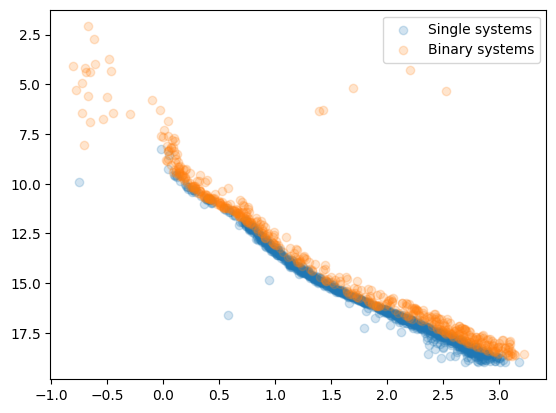

In [8]:
# Mask to identify binary systems given a probability cut value
msk = stellar_data['binar_prob'] > 0.5
import matplotlib.pyplot as plt
plt.scatter(my_cluster.color[~msk], my_cluster.mag[~msk], alpha=.2, label='Single systems')
plt.scatter(my_cluster.color[msk], my_cluster.mag[msk], alpha=.2, label='Binary systems')
plt.legend()
plt.gca().invert_yaxis();

Notice that stars in the BSS region of the CMD (brighter and bluer than the turn-off point) are also identified as very probable binary systems.  As explained in [Synthetic module](../synthetic_mod), the binary probabilities for BSSs are not accurate and should not be used.

The following section explains how to estimate the cluster's total binary fraction taking this into account.

## Binary fraction

As detailed in [Synthetic module](../synthetic_mod), there is no *total binary fraction* parameter fitted when using the synthetic clusters, as this is handled through the `alpha, beta` parameters. The binary fraction parameter can be easily estimated using the probabilities found above, as follows:

In [9]:
# Extract the per-star binary probabilities
binar_probs = stellar_data['binar_prob']

# Exclude nan values (stars with bad photometry)
msk = ~np.isnan(binar_probs)
binar_probs = binar_probs[msk]

# Obtain mean and STDDEV of the total binary fraction for this cluster
bfr_med = np.mean(binar_probs)
# Measure the STDDEV as the standard error of the mean for Bernoulli variables
# (ie: NOT np.std(binar_probs))
bfr_std = np.sqrt(np.sum(binar_probs * (1 - binar_probs))) / len(binar_probs)
print(f"Binary fraction: {bfr_med:.2f}+/-{bfr_std:.2f}")

Binary fraction: 0.36+/-0.01


To get an estimate that is slightly more accurate, we can discard the most probable BSSs (which most likely will have large binary probabilities) before estimating the total binary fraction

In [10]:
# Extract BSS probabilities (without nan values)
bss_probs = stellar_data['bss_prob'][msk]

# Identify those stars that have a probability of being a BSS lower than 50%
msk_bss = bss_probs < 0.5

# Re estimate the meand and STDDEV of the total binary fraction for this cluster,
# now excluding those stars that are most likely BSSs
binar_probs = binar_probs[msk_bss]
bfr_med = np.mean(binar_probs)
bfr_std = np.sqrt(np.sum(binar_probs * (1 - binar_probs))) / len(binar_probs)
print(f"Binary fraction: {bfr_med:.2f}+/-{bfr_std:.2f}")

Binary fraction: 0.35+/-0.01


As we can see, the estimate is a bit smaller as we removed a few probable BSS stars that also have large probabilities of being binary systems.

The following section shows how the total number of BSSs can be estimated.

## Number of BSSs

We can obtain the number of detected BSSs using for example a probability cut of P=50%:

In [11]:
# Extract BSS probabilities
bss_probs = stellar_data['bss_prob']

# Identify as BSSs only those stars with probabilities larger tan 50%
msk_bss = bss_probs > 0.5

# Count BSSs
N_bss = msk_bss.sum()
print(f"Number of BSSs detected: {N_bss}")

Number of BSSs detected: 19


A simple plot shows which observed stars are more likely to be BSSs:

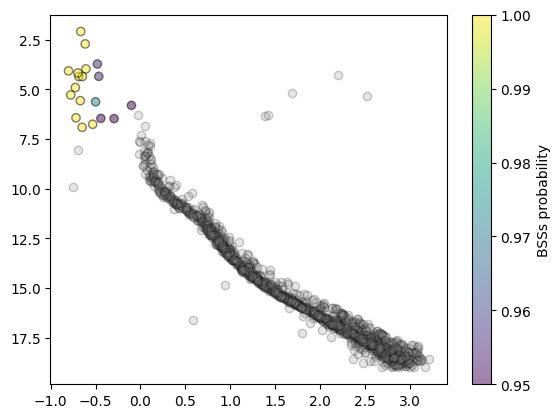

In [12]:
plt.scatter(my_cluster.color[~msk_bss], my_cluster.mag[~msk_bss], alpha=0.2, ec="k", c="grey")
plt.scatter(my_cluster.color[msk_bss], my_cluster.mag[msk_bss], alpha=0.5, ec="k", c=bss_probs[msk_bss])
cbar = plt.colorbar()
cbar.set_label("BSSs probability")
plt.gca().invert_yaxis();